In [ ]:
%matplotlib inline

# TAREA 2 -- Image Clasification for Crisis Dataset

**Adapted from:** [Nathan Inkawhich](https://github.com/inkawhich)

In this task, we will look at how to create a model for image classification, the impact of transfer learning using models pretrained on the 1000-class Imagenet dataset. The most efficient parameters for each architectures are likely to change, so you must look at the existing architecture and make custom adjustments for each model.

We will try to learn using a model **trained from scratch**, to do **feature extraction** by using only the last layer of a pre-trained network and only update the final layer weights using our data and label (i.e., using the CNN as a fixed feature extractor), and to **fine-tune** a pretrained model and update *all* of the model’s parameters for our task.

More information about transfer learning [in the CS231n class of Standford](https://cs231n.github.io/transfer-learning/) and in [Sebastian Ruder's blog post](https://ruder.io/transfer-learning/).

### Goal

The goals for you are to
* Fill up the code at different points where you have `# TODO`,
* Try different hyper-parameters of the models, different training and evaluation settings in order to answer the questions
* In the end you will have to upload an image of yours to test your model on it!   

### Data

We will use a Multimodal Crisis Dataset (https://crisisnlp.qcri.org/crisismmd), which consists of several thousands of manually annotated tweets and images collected during seven major natural disasters including earthquakes, hurricanes, wildfires, and floods that happened in the year 2017 across different parts of the World. The dataset contains three different tasks. We are going to work with task 2: Humanitarian categories, which is a classification task with eight possible labels: **"Affected individuals", "Infrastructure and utility damage", "Injured or dead people", "Missing or found people", "Rescue, volunteering or donation effort", "Vehicle damage", "Other relevant information", "Not humanitarian"**. The goal is to build a model that takes an image as input and predicts the apropiate humanitarian category.

### Before Starting! Some tips on GPU and Google Colab

You will likely to run this code on Google Colab in order to use GPU ressources. If not, the code will take 60 times more to run!!  

Colab will disconnect you if you the training is too long. In order to prevent this, you can use this piece of code in the console of your browser:

```java
function ClickConnect(){
console.log("Working");
document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect,60000)
```

See more [here](https://www.reddit.com/r/StableDiffusion/comments/xhhlp0/automatic1111_on_colab_how_to_keep_it_running/).

Have fun!

In [ ]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import json
import copy
from tqdm import tqdm
import shutil
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import pandas as pd
import seaborn as sn
from datasets import load_dataset
import numpy as np

from torch.utils.data import Dataset,DataLoader

print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

INIT_PATH = '/content/drive/My Drive/'
print('INIT_PATH : {}'.format(INIT_PATH))

PyTorch Version:  2.8.0+cu126
Torchvision Version:  0.23.0+cu126
INIT_PATH : /content/drive/My Drive/


## Loading the data
Download and unzip the dataset

In [ ]:
!wget https://users.dcc.uchile.cl/~hjimenez/data/CrisisMMD_v2.0.tar.gz
!tar zxvf CrisisMMD_v2.0.tar.gz
!unzip /content/CrisisMMD_v2.0/crisismmd_datasplit_all.zip

Streaming output truncated to the last 5000 lines.
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909482765850107904_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909492601702813697_1.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909395364133863424_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909453691752783873_1.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909387311938281473_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909406366002929664_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909421112496349190_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909419339845120001_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909388598587379713_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909419682993713153_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909484808404967425_0.jpg
CrisisMMD_v2.0/data_image/hurricane_irma/17_9_2017/909447136588193793_0.jpg
CrisisMMD_v2.0/data_image/hurricane_i

In [ ]:
def load_crisismmd_tsv(path):
    '''
    Load tsv file that contains annotations for task in CrisisMMD dataset
    '''
    rows = []
    with open(path, encoding="utf-8") as f:
        header = f.readline().strip().split("\t")
        expected_cols = len(header)

        for line in f:
            parts = line.rstrip("\n").split("\t")

            if len(parts) == expected_cols:
                rows.append(parts)
            elif len(parts) > expected_cols:
                fixed = parts[:4] + [" ".join(parts[4:len(parts)-(expected_cols-5)])] + parts[-(expected_cols-5):]
                rows.append(fixed)
            else:
                print("skiping line")
                continue

    df = pd.DataFrame(rows, columns=header)
    return df

def load_annotations(task="humanitarian",data_dir="/content/"):
    '''
    Load annotations for all splits
    '''
    datasplits = {}

    for split in ["train","dev","test"]:
        df = load_crisismmd_tsv(os.path.join(data_dir,f"crisismmd_datasplit_all/task_{task}_text_img_{split}.tsv"))
        df = df.rename(columns={"image":"image_path"})
        if split == "dev": #val is the same as dev
            datasplits["val"] = df
        else:
            datasplits[split] = df

    return datasplits

class CrisisMMDVisionDataset(Dataset):
    def __init__(self,annotations,img_dir,class_to_idx,transform=None):
        self.annotations = annotations
        self.img_dir = img_dir
        self.transform = transform

        self.images_path = [example for example in self.annotations["image_path"]]
        self.labels      = [example for example in self.annotations["num_label"]]

        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.images_path[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, label

In [ ]:
annotations = load_annotations(task="humanitarian",data_dir="/content/")
#we construct the labels
unique_labels = annotations["train"]["label_image"].unique()
labels_to_idx = { l:i for i,l in enumerate(unique_labels) }
idx_to_labels = { i:l for l,i in labels_to_idx.items() }

for split in ["train","val","test"]:
    annotations[split]["num_label"] = [ labels_to_idx[ lab ] for lab in annotations[split]["label_image"]  ]

In [ ]:
print(labels_to_idx)
print(idx_to_labels)
print("an example of the data")
print(annotations["train"].iloc[0])

{'not_humanitarian': 0, 'infrastructure_and_utility_damage': 1, 'vehicle_damage': 2, 'rescue_volunteering_or_donation_effort': 3, 'other_relevant_information': 4, 'affected_individuals': 5, 'injured_or_dead_people': 6, 'missing_or_found_people': 7}
{0: 'not_humanitarian', 1: 'infrastructure_and_utility_damage', 2: 'vehicle_damage', 3: 'rescue_volunteering_or_donation_effort', 4: 'other_relevant_information', 5: 'affected_individuals', 6: 'injured_or_dead_people', 7: 'missing_or_found_people'}
an example of the data
event_name                                       california_wildfires
tweet_id                                           917791291823591425
image_id                                         917791291823591425_1
tweet_text          RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...
image_path          data_image/california_wildfires/10_10_2017/917...
label                                                not_humanitarian
label_text                                 other_relevant_i

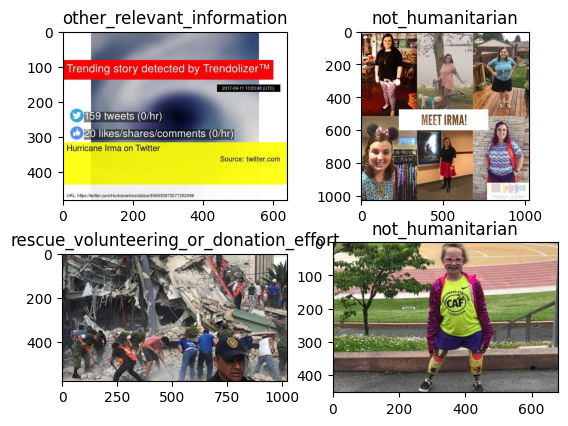

In [ ]:
#check an example of the data
import math
fig, axes = plt.subplots(2,2)
for i, index in enumerate([4,500,800,100]): # some random indexes
  example = annotations["val"].iloc[index]
  img = np.asarray(Image.open(f"/content/CrisisMMD_v2.0/{example["image_path"]}"))
  axes[ i // 2 , i % 2 ].imshow(img)
  axes[ i // 2 , i % 2 ].set_title(example["label_image"])


### Inputs
   
The inputs you will have to play with:
* ``feature_extract`` is a boolean that defines if we are finetuning or feature extracting. If ``feature_extract = False``, the model is finetuned and all model parameters are updated. If ``feature_extract = True``, only the last layer parameters are updated, the others remain fixed
* ``use_pretrained`` is a boolean that defines if fine-tuning with a model pre-trained over ImageNet or training a model from scratch
* `data_augmentation` is a boolean that defines whether or not we will use data-augmentation
* `model_name` The name of the model you wish to use and must be selected from this list: ['resnet', 'alexnet', 'vgg', 'squeezenet', 'densenet']

The other inputs are as follows:
* ``num_classes`` is the number of classes in the dataset, which is 8 in our case
* ``batch_size`` is the batch size used for training and may be adjusted according to the capability of your machine, ``num_epochs`` is the number of training epochs we want to run,
* `lr` which is the learning rate of the optimizer

In [ ]:
#number of classes
num_classes = len(unique_labels)

# Batch size for training (change depending on how much memory you have)
batch_size = 64

# Number of epochs to train for
num_epochs = 10

#model name
model_name = "resnet"

# learning rate of the optimizer
lr=0.001

# Flag for pre-training. When False, we train a model from scratch,
#   when True we fine-tune a model already pretrained over ImageNet
use_pretrained=True

# Flag for feature extracting. When False, we finetune the whole model,
#   when True we only update the reshaped layer params
feature_extract = True

# Flag for data augmentation. When True apply a random cropped, a random
#   flip on the training images, and a rotation.
data_augmentation = True

# Setup the loss fxn
criterion = nn.CrossEntropyLoss()

## Creation Datasets and Dataloaders

Regarding Data Augmentation, use `transforms.RandomResizedCrop` and `transforms.RandomHorizontalFlip`, and also `transforms.RandomRotation` to see which one works best

In [ ]:
def return_datasets_dataloaders(DatasetClass,
                                annotations,
                                data_dir="./data",
                                input_size=224,
                                angle_rotation=5,
                                data_augmentation = True):
    """
    Create the datasets and dataloaders needed for the training
    """

    # apply data augmentation
    list_data_transform_data_aug = [
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(angle_rotation),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ]
    # test without data_augmentation
    list_data_transform = [
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
    ]


    # Data augmentation and normalization for training
    # Just normalization for validation and test
    if data_augmentation:
        data_transforms = {
            'train': transforms.Compose(list_data_transform_data_aug),
            'val': transforms.Compose(list_data_transform),
            'test': transforms.Compose(list_data_transform),
        }
    else: # no data augmentation in this case
        data_transforms = {
            'train': transforms.Compose(list_data_transform),
            'val': transforms.Compose(list_data_transform),
            'test': transforms.Compose(list_data_transform),
        }


    print("Initializing Datasets and Dataloaders"+data_augmentation*" with data augmentation"+"...")


    # Create training, validation and test datasets
    split_names = ['train', 'val', 'test']
    image_datasets = {x: DatasetClass(annotations=annotations[x],
                                      img_dir=data_dir,
                                      class_to_idx=labels_to_idx,
                                      transform= data_transforms[x]) for x in split_names}

    # Create training, validation and test dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x],
                                                       batch_size=batch_size,
                                                       shuffle=(x == 'train'),
                                                       num_workers=2) for x in split_names}

    return image_datasets, dataloaders_dict

image_datasets, dataloaders_dict = return_datasets_dataloaders(CrisisMMDVisionDataset,
                                                               annotations=annotations,
                                                               data_dir ="/content/CrisisMMD_v2.0/" ,
                                                               data_augmentation = data_augmentation)

# Detect if we have a GPU available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Initializing Datasets and Dataloaders with data augmentation...


In [ ]:
next(iter(dataloaders_dict["train"])) # an example, if data augmentation are perform well, it should work

[tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           ...,
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
          [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           ...,
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
          [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
           [-

Helper Functions
----------------

Before we write the code for adjusting the models, lets define a few
helper functions.

**Model Training and Validation Code**

The ``train_model`` function handles the training and validation of a
given model. As input, it takes a PyTorch model, a dictionary of
dataloaders, a loss function, an optimizer, a specified number of epochs
to train and validate for, and a boolean flag for when the model is an
Inception model.
The function trains for the specified number of epochs and after each
epoch runs a full validation step. It also keeps track of the best
performing model (in terms of validation accuracy), and at the end of
training returns the best performing model. After each epoch, the
training and validation accuracies are printed.


In [ ]:
def update_lists_for_f1_score(preds, labels, target_true, predicted_true, correct_true, all_labels):
  """
  Need to be executed at every batch in order to update the lists target_true, predicted_true and correct_true.
  target = TP + FN
  predicted_true = TP + FP
  correct_true = TP
  """
  # iterating over all the classes
  for class_k in all_labels:
    predicted_classes = preds == class_k
    target_classes = labels == class_k
    target_true[class_k] += torch.sum(target_classes).float()
    predicted_true[class_k] += torch.sum(predicted_classes).float()
    correct_true[class_k] += torch.sum(
        (predicted_classes) * (target_classes)).float()
  return target_true, predicted_true, correct_true

def train_model(model, dataloaders, criterion, optimizer, num_epochs=25,
                   use_tqdm=False, name_model = 'best_model_no_feature_extraction.pt'):
    since = time.time()
    t0 = since

    val_acc_history = []
    val_loss_history = []
    train_acc_history = []
    train_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # to initialize the counters of the true
    dico_labels = image_datasets['val'].class_to_idx
    dico_labels_inverse = {v:k for k, v in dico_labels.items()}
    all_labels = dico_labels.values()
    dict_true_init = {idx_lab : 0 for idx_lab in all_labels}

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            # Set model to training/evaluate mode
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            target_true = dict_true_init.copy()
            predicted_true = dict_true_init.copy()
            correct_true = dict_true_init.copy()

            # Iterate over data.
            array_for_loop = dataloaders[phase]
            if use_tqdm or (epoch == 0): # training is slow at 1st epoch
              array_for_loop = tqdm(array_for_loop)
            for inputs, labels in array_for_loop:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                # TODO
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    # Get model outputs and calculate loss
                    # TODO
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # create predictions
                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    # TODO
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                target_true, predicted_true, correct_true = update_lists_for_f1_score(preds, labels.data,
                                                    target_true, predicted_true, correct_true, all_labels)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            # calculating F1
            recall = []
            precision = []
            f1_score = []
            # At the end of the epoch
            for k_class in range(len(set(all_labels))):
                recall.append(correct_true[k_class] / target_true[k_class])
                precision.append(correct_true[k_class] / predicted_true[k_class])
                f1_score.append(2 * precision[k_class] * recall[k_class] / (precision[k_class] + recall[k_class]))

            epoch_f1 = np.mean([k.cpu().numpy() for k in f1_score])

            time_epoch = time.time()-t0
            print('{} Loss: {:.4f} Acc: {:.4f}  F1: {:.4f} in {:.0f}m {:.0f}s'.format(phase, epoch_loss, epoch_acc,
                                                                          epoch_f1, time_epoch // 60, time_epoch % 60))
            # write the F1 per label
            # if phase == 'val':
            if True:
                str_to_write = 'F1 : '
                for k, v in dico_labels.items():
                    str_to_write += "'{}' : {:.4f}, ".format(k, f1_score[v])
                print(str_to_write)

            t0 = time.time()

            # deep copy the model if best accuracy in this epoch
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                print('Best model saved')
                torch.save(model, 'temp_' + name_model)
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'val':
                val_acc_history.append(epoch_acc)
                val_loss_history.append(epoch_loss)
            else:
              train_acc_history.append(epoch_acc)
              train_loss_history.append(epoch_loss)

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, (val_acc_history, val_loss_history), (train_acc_history, train_loss_history)

#### Set Model Parameters’ .requires_grad attribute

This helper function sets the ``.requires_grad`` attribute of the
parameters in the model to False when we are feature extracting. By
default, when we load a pretrained model all of the parameters have
``.requires_grad=True``, which is fine if we are training from scratch
or finetuning. However, if we are feature extracting and only want to
compute gradients for the newly initialized layer then we want all of
the other parameters to not require gradients. This will make more sense
later.




In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

## Initialize and Reshape the Networks


Now to the most interesting part. Here is where we handle the reshaping
of each network. Note, this is not an automatic procedure and is unique
to each model. Recall, the final layer of a CNN model, which is often
times an FC layer, has the same number of nodes as the number of output
classes in the dataset. Since all of the models have been pretrained on
Imagenet, they all have output layers of size 1000, one node for each
class. The goal here is to reshape the last layer to have the same
number of inputs as before, AND to have the same number of outputs as
the number of classes in the dataset. In the following sections we will
discuss how to alter the architecture of each model individually. But
first, there is one important detail regarding the difference between
finetuning and feature-extraction.

When feature extracting, we only want to update the parameters of the
last layer, or in other words, we only want to update the parameters for
the layer(s) we are reshaping. Therefore, we do not need to compute the
gradients of the parameters that we are not changing, so for efficiency
we set the .requires_grad attribute to False. This is important because
by default, this attribute is set to True. Then, when we initialize the
new layer and by default the new parameters have ``.requires_grad=True``
so only the new layer’s parameters will be updated. When we are
finetuning we can leave all of the .required_grad’s set to the default
of True.

### Resnet

Resnet was introduced in the paper [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385). There are several variants of different sizes, including Resnet18, Resnet34, Resnet50, Resnet101, and Resnet152, all of which are available from torchvision models. Here we use Resnet18, as our dataset is small and only has two classes. When we print the model, we see that the last layer is a fully connected layer as shown below:

```
   (fc): Linear(in_features=512, out_features=1000, bias=True)
```

Thus, we must reinitialize ``model.fc`` to be a Linear layer with 512
input features and 2 output features with:

```
   model.fc = nn.Linear(512, num_classes)
```

### Alexnet


Alexnet was introduced in the paper [ImageNet Classification with Deep Convolutional Neural Networks](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) and was the first very successful CNN on the ImageNet dataset. When we print the model architecture, we see the model output comes from the 6th layer of the classifier

```

   (classifier): Sequential(
       ...
       (6): Linear(in_features=4096, out_features=1000, bias=True)
    )
```
To use the model with our dataset we reinitialize this layer as

```
   model.classifier[6] = nn.Linear(4096,num_classes)
```

### VGG

VGG was introduced in the paper [Very Deep Convolutional Networks for
Large-Scale Image Recognition](https://arxiv.org/pdf/1409.1556.pdf). Torchvision offers eight versions of VGG with various lengths and some that have batch normalizations layers. Here we use VGG-11 with batch normalization. The output layer is similar to Alexnet, i.e.

```

   (classifier): Sequential(
       ...
       (6): Linear(in_features=4096, out_features=1000, bias=True)
    )
```
Therefore, we use the same technique to modify the output layer

```

   model.classifier[6] = nn.Linear(4096,num_classes)
```

### Squeezenet


The Squeeznet architecture is described in the paper [SqueezeNet:
AlexNet-level accuracy with 50x fewer parameters and <0.5MB model
size](https://arxiv.org/abs/1602.07360) and uses a different output
structure than any of the other models shown here. Torchvision has two
versions of Squeezenet, we use version 1.0. The output comes from a 1x1
convolutional layer which is the 1st layer of the classifier:

```

   (classifier): Sequential(
       (0): Dropout(p=0.5)
       (1): Conv2d(512, 1000, kernel_size=(1, 1), stride=(1, 1))
       (2): ReLU(inplace)
       (3): AvgPool2d(kernel_size=13, stride=1, padding=0)
    )
```

To modify the network, we reinitialize the Conv2d layer to have an
output feature map of depth 2 as

```

   model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
```

### Densenet

Densenet was introduced in the paper [Densely Connected Convolutional
Networks](https://arxiv.org/abs/1608.06993). Torchvision has four
variants of Densenet but here we only use Densenet-121. The output layer
is a linear layer with 1024 input features:

```
   (classifier): Linear(in_features=1024, out_features=1000, bias=True)

```

To reshape the network, we reinitialize the classifier’s linear layer as

```
   model.classifier = nn.Linear(1024, num_classes)
```

Notice, many of the models have similar output structures, but each must
be handled slightly differently. Also, check out the printed model
architecture of the reshaped network and make sure the number of output
features is the same as the number of classes in the dataset.

In [ ]:
from torchvision import models
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    AlexNet_Weights,
    VGG11_BN_Weights,
    SqueezeNet1_0_Weights,
    DenseNet121_Weights
)
import torch.nn as nn

def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    # Initialize these variables which will be set in this if statement. Each of these
    #   variables is model specific.
    model_ft = None
    input_size = 0

    # Helper para cargar pesos o None
    def get_weights(weights_class):
        return weights_class.DEFAULT if use_pretrained else None

    if model_name == "resnet":
        weights = get_weights(ResNet18_Weights)
        model_ft = models.resnet18(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)

    elif model_name == "resnet50":
        weights = get_weights(ResNet50_Weights)
        model_ft = models.resnet50(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)

    elif model_name == "alexnet":
        weights = get_weights(AlexNet_Weights)
        model_ft = models.alexnet(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[6] = nn.Linear(model_ft.classifier[6].in_features, num_classes)

    elif model_name == "vgg":
        weights = get_weights(VGG11_BN_Weights)
        model_ft = models.vgg11_bn(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[6] = nn.Linear(model_ft.classifier[6].in_features, num_classes)

    elif model_name == "squeezenet":
        weights = get_weights(SqueezeNet1_0_Weights)
        model_ft = models.squeezenet1_0(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1))
        model_ft.num_classes = num_classes

    elif model_name == "densenet":
        weights = get_weights(DenseNet121_Weights)
        model_ft = models.densenet121(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier = nn.Linear(model_ft.classifier.in_features, num_classes)

    else:
        raise ValueError(f"Invalid model name: {model_name}")

    return model_ft, input_size

Create the Optimizer
--------------------

Now that the model structure is correct, the final step for finetuning
and feature extracting is to create an optimizer that only updates the
desired parameters. Recall that after loading the pretrained model, but
before reshaping, if ``feature_extract=True`` we manually set all of the
parameter’s ``.requires_grad`` attributes to False. Then the
reinitialized layer’s parameters have ``.requires_grad=True`` by
default. So now we know that *all parameters that have
.requires_grad=True should be optimized.* Next, we make a list of such
parameters and input this list to the SGD algorithm constructor.

To verify this, check out the printed parameters to learn. When
finetuning, this list should be long and include all of the model
parameters. However, when feature extracting this list should be short
and only include the weights and biases of the reshaped layers.




In [ ]:
# See subsection "inputs" to understand each parameter

configs = [
    {
      "model_name": "resnet",
      "feature_extract": False,
      "use_pretrained": True,
    },
    {
      "model_name": "resnet",
      "feature_extract": True,
      "use_pretrained": True,
    },
    {
      "model_name": "vgg",
      "feature_extract": True,
      "use_pretrained": True,
    },
    {
      "model_name": "squeezenet",
      "feature_extract": True,
      "use_pretrained": True,
    }
]

# Initialize the models
modelos_inicializados = []

for config in configs:
    model_name = config["model_name"]
    feature_extract = config["feature_extract"]
    use_pretrained = config["use_pretrained"]

    print(f"Model: {model_name}\nMode: {'feature extraction' if feature_extract else 'fine tuning'}")

    model_ft, input_size = initialize_model(model_name=model_name, num_classes=num_classes, feature_extract=feature_extract, use_pretrained=use_pretrained)

    # Send the model to GPU
    model_ft = model_ft.to(device)

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    if feature_extract:
        params_to_update = [param for param in model_ft.parameters() if param.requires_grad]
    else:
        params_to_update = model_ft.parameters()

    print("Params to learn:")
    for name, param in model_ft.named_parameters():
        if param.requires_grad:
            print(f"\t{name}")
    print("\n\n")

    optimizer_ft = optim.SGD(params_to_update, lr=lr, momentum=0.9)

    modelos_inicializados.append({
        "config": config,
        "model": model_ft,
        "optimizer": optimizer_ft,
        "input_size": input_size
    })


Model: resnet
Mode: fine tuning
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 285MB/s]


Params to learn:
	conv1.weight
	bn1.weight
	bn1.bias
	layer1.0.conv1.weight
	layer1.0.bn1.weight
	layer1.0.bn1.bias
	layer1.0.conv2.weight
	layer1.0.bn2.weight
	layer1.0.bn2.bias
	layer1.1.conv1.weight
	layer1.1.bn1.weight
	layer1.1.bn1.bias
	layer1.1.conv2.weight
	layer1.1.bn2.weight
	layer1.1.bn2.bias
	layer2.0.conv1.weight
	layer2.0.bn1.weight
	layer2.0.bn1.bias
	layer2.0.conv2.weight
	layer2.0.bn2.weight
	layer2.0.bn2.bias
	layer2.0.downsample.0.weight
	layer2.0.downsample.1.weight
	layer2.0.downsample.1.bias
	layer2.1.conv1.weight
	layer2.1.bn1.weight
	layer2.1.bn1.bias
	layer2.1.conv2.weight
	layer2.1.bn2.weight
	layer2.1.bn2.bias
	layer3.0.conv1.weight
	layer3.0.bn1.weight
	layer3.0.bn1.bias
	layer3.0.conv2.weight
	layer3.0.bn2.weight
	layer3.0.bn2.bias
	layer3.0.downsample.0.weight
	layer3.0.downsample.1.weight
	layer3.0.downsample.1.bias
	layer3.1.conv1.weight
	layer3.1.bn1.weight
	layer3.1.bn1.bias
	layer3.1.conv2.weight
	layer3.1.bn2.weight
	layer3.1.bn2.bias
	layer4.0.conv1

100%|██████████| 507M/507M [00:03<00:00, 136MB/s] 


Params to learn:
	classifier.6.weight
	classifier.6.bias



Model: squeezenet
Mode: feature extraction
Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 78.5MB/s]

Params to learn:
	classifier.1.weight
	classifier.1.bias





Run Training and Validation Step
--------------------------------

Finally, the last step is to setup the loss for the model, then run the
training and validation function for the set number of epochs. Notice,
depending on the number of epochs this step may take a while on a CPU.
Also, the default learning rate is not optimal for all of the models, so
to achieve maximum accuracy it would be necessary to tune for each model
separately.




In [15]:
data_dir = "./models"
os.makedirs(data_dir, exist_ok=True)

history_data = {}

for model_info in modelos_inicializados:
    config = model_info["config"]
    model_name = config["model_name"]
    model_ft = model_info["model"]
    optimizer_ft = model_info["optimizer"]
    feature_extract = config["feature_extract"]

    name_base = (
        f"{model_name}_best_model_"
        f"{'no_' if not feature_extract else ''}feature_extraction"
        f"{'_data_augmentation' if config.get('data_augmentation', False) else ''}"
    )
    name_model = f"{name_base}.pt"

    print(f"\nEntrenando {name_model}")

    model_ft, hist_val, hist_train = train_model(
        model_ft,
        dataloaders_dict,
        criterion,
        optimizer_ft,
        num_epochs=num_epochs,
        use_tqdm=True,
        name_model=name_model
    )

    # Saving the weights
    save_path = os.path.join(data_dir, name_model)
    torch.save(model_ft.state_dict(), save_path)

    # Saving the historical losses
    history_data[name_model] = {
        "hist_val": hist_val,
        "hist_train": hist_train
    }

    # Deleting temp files
    temp_path = f"temp_{name_model}"
    if os.path.exists(temp_path):
        os.remove(temp_path)


Entrenando resnet_best_model_no_feature_extraction.pt
Epoch 0/9
----------


 54%|█████▍    | 115/213 [00:52<00:35,  2.73it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 213/213 [01:35<00:00,  2.24it/s]


train Loss: 0.6862 Acc: 0.7496  F1: nan in 1m 35s
F1 : 'not_humanitarian' : 0.8198, 'infrastructure_and_utility_damage' : 0.7549, 'vehicle_damage' : 0.4540, 'rescue_volunteering_or_donation_effort' : 0.5907, 'other_relevant_information' : 0.7176, 'affected_individuals' : 0.2832, 'injured_or_dead_people' : 0.3621, 'missing_or_found_people' : nan, 


 80%|████████  | 28/35 [00:13<00:02,  2.41it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 35/35 [00:17<00:00,  1.96it/s]

val Loss: 0.7399 Acc: 0.7287  F1: nan in 0m 18s
F1 : 'not_humanitarian' : 0.8070, 'infrastructure_and_utility_damage' : 0.7374, 'vehicle_damage' : 0.3607, 'rescue_volunteering_or_donation_effort' : 0.5882, 'other_relevant_information' : 0.6928, 'affected_individuals' : 0.2222, 'injured_or_dead_people' : 0.3636, 'missing_or_found_people' : nan, 
Best model saved

Epoch 1/9
----------


...

val Loss: 0.8832 Acc: 0.6826  F1: nan in 0m 17s
F1 : 'not_humanitarian' : 0.7557, 'infrastructure_and_utility_damage' : 0.6971, 'vehicle_damage' : 0.3019, 'rescue_volunteering_or_donation_effort' : 0.5579, 'other_relevant_information' : 0.6614, 'affected_individuals' : 0.1250, 'injured_or_dead_people' : 0.3077, 'missing_or_found_people' : nan, 

Epoch 9/9
----------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train Loss: 0.8846 Acc: 0.6816  F1: nan in 1m 29s
F1 : 'not_humanitarian' : 0.7638, 'infrastructure_and_utility_damage' : 0.6870, 'vehicle_damage' : 0.2403, 'rescue_volunteering_or_donation_effort' : 0.4726, 'other_relevant_information' : 0.6476, 'affected_individuals' : 0.1253, 'injured_or_dead_people' : 0.2364, 'missing_or_found_people' : nan, 


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


val Loss: 0.8838 Acc: 0.6942  F1: nan in 0m 18s
F1 : 'not_humanitarian' : 0.7784, 'infrastructure_and_utility_damage' : 0.7009, 'vehicle_damage' : 0.1702, 'rescue_volunteering_or_donation_effort' : 0.4726, 'other_relevant_information' : 0.6724, 'affected_individuals' : 0.1429, 'injured_or_dead_people' : 0.3636, 'missing_or_found_people' : nan, 
Best model saved

Training complete in 18m 0s
Best val Acc: 0.694233


In [17]:
# Parse torch data to json format
def tensor_to_list(x):
    """Convierte tensores o listas de tensores a listas nativas."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().tolist()
    elif isinstance(x, (list, tuple)):
        return [tensor_to_list(i) for i in x]

    return x

history_data_serializable = {
    model_name: {
        "train_acc": tensor_to_list(hist["hist_train"][0]),
        "train_loss": tensor_to_list(hist["hist_train"][1]),
        "val_acc": tensor_to_list(hist["hist_val"][0]),
        "val_loss": tensor_to_list(hist["hist_val"][1])
    }
    for model_name, hist in history_data.items()
}

# Save historical acc and losses in a json file
with open(os.path.join(data_dir, "history_data.json"), "w") as f:
    json.dump(history_data_serializable, f)

#### Plot hist

In [21]:
def plot_hist(hist_val, hist_train, num_epochs):
    """
    Plot the training and validation accuracy and loss curves on the same figure with two y-axes.
    """
    # hist_val_acc, hist_val_loss = hist_val
    # hist_train_acc, hist_train_loss = hist_train

    # val_acc = [h.cpu().numpy() for h in hist_val_acc]
    # val_loss = [h for h in hist_val_loss]
    # train_acc = [h.cpu().numpy() for h in hist_train_acc]
    # train_loss = [h for h in hist_train_loss]

    val_acc, val_loss = hist_val
    train_acc, train_loss = hist_train

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot accuracy on the primary y-axis
    ax1.set_xlabel('Training Epochs')
    ax1.set_ylabel('Accuracy', color='blue')
    ax1.plot(range(1, num_epochs + 1), val_acc, label="Validation Accuracy", linestyle='-', marker='o', color='blue')
    ax1.plot(range(1, num_epochs + 1), train_acc, label="Training Accuracy", linestyle='-', marker='x', color='cyan')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim([0, 1])  # Accuracy range

    # Create a secondary y-axis for loss
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    ax2.set_ylabel('Loss', color='red')
    ax2.plot(range(1, num_epochs + 1), val_loss, label="Validation Loss", linestyle='--', marker='o', color='red')
    ax2.plot(range(1, num_epochs + 1), train_loss, label="Training Loss", linestyle='--', marker='x', color='orange')
    ax2.tick_params(axis='y', labelcolor='red')

    # Add legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title("Accuracy and Loss vs. Number of Training Epochs")
    plt.xticks(np.arange(1, num_epochs + 1, 1.0))

    fig.tight_layout()  # To make sure everything fits without overlap
    plt.grid(True)
    plt.show()

Model: resnet_best_model_no_feature_extraction.pt


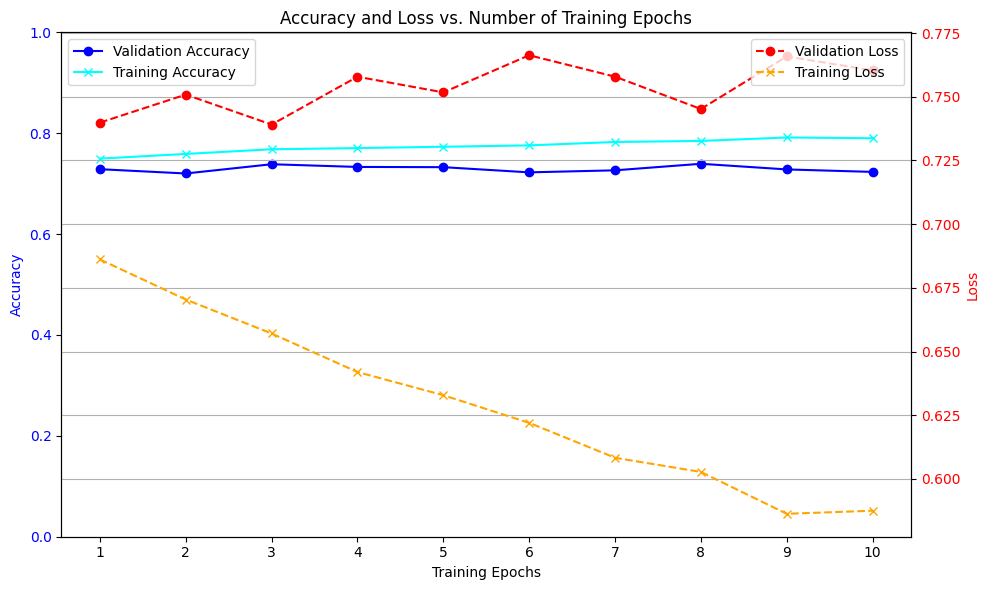

Model: resnet_best_model_feature_extraction.pt


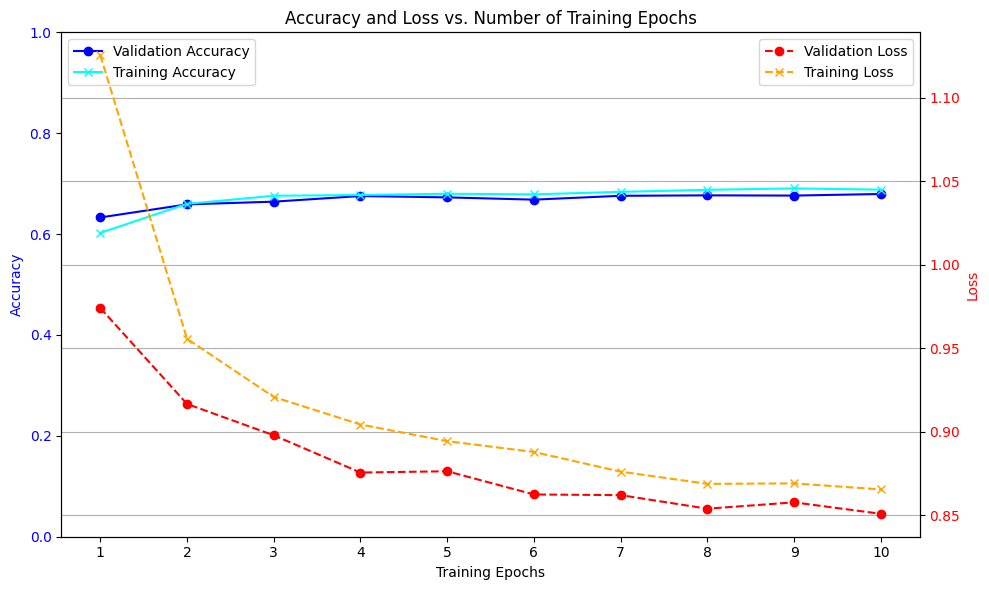

Model: vgg_best_model_feature_extraction.pt


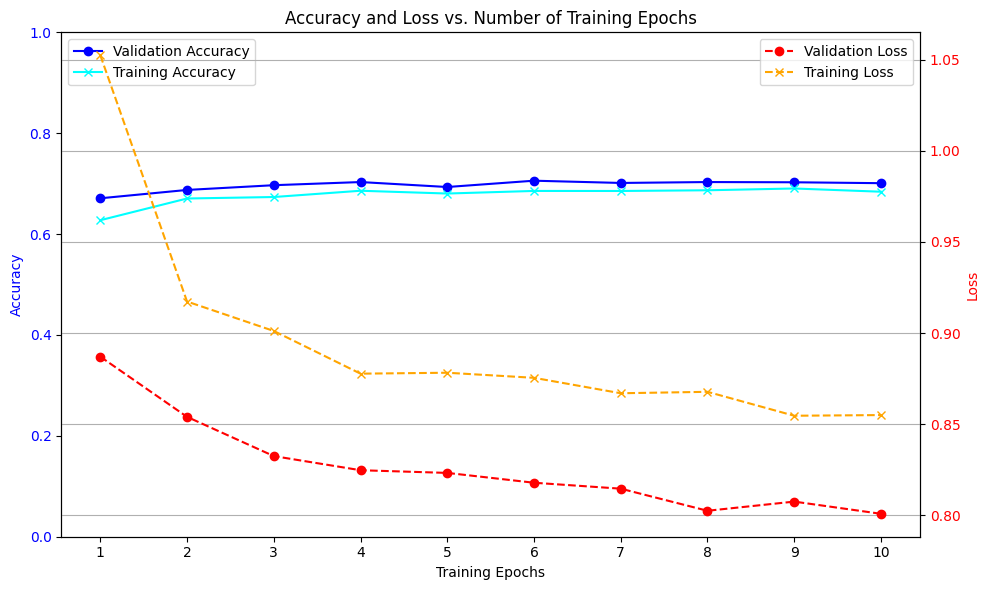

Model: squeezenet_best_model_feature_extraction.pt


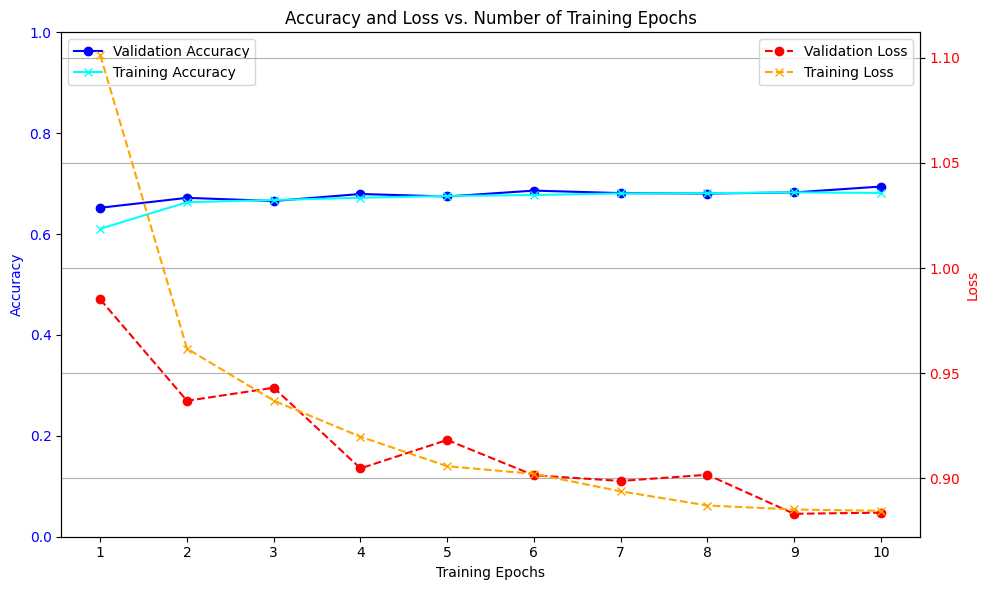

In [22]:
with open(os.path.join(data_dir, "history_data.json"), "r") as f:
    history_data = json.load(f)

for name, hist in history_data.items():
    print(f"Model: {name}")
    hist_val = (hist["val_acc"], hist["val_loss"])
    hist_train = (hist["train_acc"], hist["train_loss"])

    plot_hist(hist_val=hist_val, hist_train=hist_train, num_epochs=num_epochs)

### Evaluate your model with test dataset

In [29]:
from sklearn.metrics import accuracy_score, f1_score

data_dir = "/content/models"

# Dict for metrics
results = {}

for config in configs:
    model_name = config["model_name"]
    feature_extract = config["feature_extract"]

    # Inverse engineering to get the path of my models
    name_base = (
        f"{model_name}_best_model_"
        f"{'no_' if not feature_extract else ''}feature_extraction"
        f"{'_data_augmentation' if config.get('data_augmentation', False) else ''}"
    )
    weights_path = os.path.join(data_dir, f"{name_base}.pt")

    # Since we only have the weights we must copy the architecture
    model_ft, _ = initialize_model(
        model_name=model_name,
        num_classes=num_classes,
        feature_extract=feature_extract,
        use_pretrained=False
    )

    # # Now we replace the weights with the trained ones, send the model to devide and put it on eval mode
    model_ft.load_state_dict(torch.load(weights_path, map_location=device))
    model_ft = model_ft.to(device)
    model_ft.eval()

    all_preds = []
    all_labels = []
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_ft(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())

    num_test_samples = len(test_loader.dataset)
    test_loss /= num_test_samples

    test_accuracy = accuracy_score(all_labels, all_preds)
    test_f1_macro = f1_score(all_labels, all_preds, average='macro')
    test_f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    # Save results
    results[name_base] = {
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted
    }

    print(f"\nResultados para {name_base}:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Macro F1: {test_f1_macro:.4f}")
    print(f"Test Weighted F1: {test_f1_weighted:.4f}")


Resultados para resnet_best_model_no_feature_extraction:
Test Loss: 0.7137
Test Accuracy: 0.7523
Test Macro F1: 0.4995
Test Weighted F1: 0.7409

Resultados para resnet_best_model_feature_extraction:
Test Loss: 0.8092
Test Accuracy: 0.7045
Test Macro F1: 0.4521
Test Weighted F1: 0.6934

Resultados para vgg_best_model_feature_extraction:
Test Loss: 0.7678
Test Accuracy: 0.7161
Test Macro F1: 0.4214
Test Weighted F1: 0.6972

Resultados para squeezenet_best_model_feature_extraction:
Test Loss: 0.8305
Test Accuracy: 0.7081
Test Macro F1: 0.4036
Test Weighted F1: 0.6866


In [30]:
# Best model (based on the previous F1)
weights_path = "/content/models/resnet_best_model_no_feature_extraction.pt"

best_model, _ = initialize_model(
    model_name="resnet",
    num_classes=num_classes,
    feature_extract=False,
    use_pretrained=False
)
best_model.load_state_dict(torch.load(weights_path, map_location=device))
best_model = best_model.to(device)

### Some visualizations

We keep one model under the name `'fine_tune_total_best_accuracy.pt'` that obtained the scores below so that we can check it's F1 score.

Let's have a look at the model's predictions with
* the confusion matrix to see between which class is the confusion
* the top-N predictions to see if the model predict in which position it predicts the right class. It is important as emotion can be multi-class and are subjectives
* A aggregation of the emotions regarding their valence (positiveness)

In [31]:
def calc_preds_with_topN(outputs, y_true, N=3):
    """
    Put the prediction as the GT if the GT is in the top-N predictions of the model
    """

    preds_sorted = torch.argsort(outputs, dim = 1, descending = True)

    # bool_preds is true if the prediction is in the top-N
    bool_preds = preds_sorted[:,0] == y_true
    for i in range(1, N):
      bool_preds += preds_sorted[:,i] == y_true

    y_hat = (~bool_preds)*preds_sorted[:,0] + bool_preds*y_true

    return y_hat

def return_y(model, dataloaders, phase='val', topNresults=None):
    """
    TODO
    Function to return the predicted and true labels from the model during inference.

    Args:
    model: The trained model to be evaluated.
    dataloaders: A dictionary containing data loaders for different phases (e.g., 'train', 'val', 'test').
    phase: The phase to be used for evaluation (default is 'val').
    topNresults: If provided, the function will return top N predictions, otherwise, it returns the highest prediction.

    Returns:
    y_hat: A list of predicted labels.
    y_true: A list of true labels.
    """

    y_hat = []  # Initialize an empty list to store predicted labels.
    y_true = []  # Initialize an empty list to store true labels.

    # Iterate over the batches of data in the specified phase (e.g., 'val').
    for inputs, labels in dataloaders[phase]:
        # Move the input and label data to the specified device (e.g., GPU).
        # TODO
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Disable gradient calculation during inference to save memory and computation (with loop)
        # Perform a forward pass through the model to get the outputs.
        # If topNresults is specified, calculate predictions using (or not) top N probabilities using the outputs
        # (regarding the value of the boolean variable topNresults)
        # TODO
        with torch.no_grad():
            outputs = model(inputs)
            if topNresults is not None:
                preds = calc_preds_with_topN(outputs, labels, topNresults)
            else:
                preds = torch.argmax(outputs, dim=1)

        # Append the predictions and the true labels to their respective lists after moving them to the CPU.
        for pred, label in zip(preds, labels):
            y_hat.append(pred.cpu())
            y_true.append(label.cpu())

    # Return the lists of predicted and true labels.
    return y_hat, y_true


def print_conf_mat_topN(model, dataloaders, all_labels_names, show_print=False,
                        phase = 'val', topNresults=None, binary_classif = False,
                       positive_classes = [1,2]):
    """
    Allow to directly print the confusion matrix with the top-N prediction.
    Also print the associated F1.
    positive_classes refers to similar classes for example 'infrastructure_and_utility_damage'(1) and 'vehicle_damage'(2)
    """

    y_hat, y_true = return_y(model, dataloaders, phase = 'val', topNresults=topNresults)

    if binary_classif:
        y_hat = [k in positive_classes for k in y_hat]
        y_true = [k in positive_classes for k in y_true]
        all_labels_names = ['negative', 'positive']

    # simple visualization
    if show_print: print(confusion_matrix(y_true, y_hat))

    # fancy visualization using seaborn
    df_cm = pd.DataFrame(confusion_matrix(y_true, y_hat), index = all_labels_names,
                      columns = all_labels_names)
    plt.figure(figsize = (10,7))
    sn.heatmap(df_cm, annot=True)
    plt.show()

    # Print the F1 for every class
    PRINT_F1 = True
    if PRINT_F1:
        str_to_write = 'F1 : global {}, '.format(f1_score(y_true, y_hat, average='macro'))
        for labn, fs in zip(all_labels_names, f1_score(y_true, y_hat, average=None)):
            str_to_write += "'{}' : {:.4f}, ".format(labn, fs)
        print(str_to_write)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


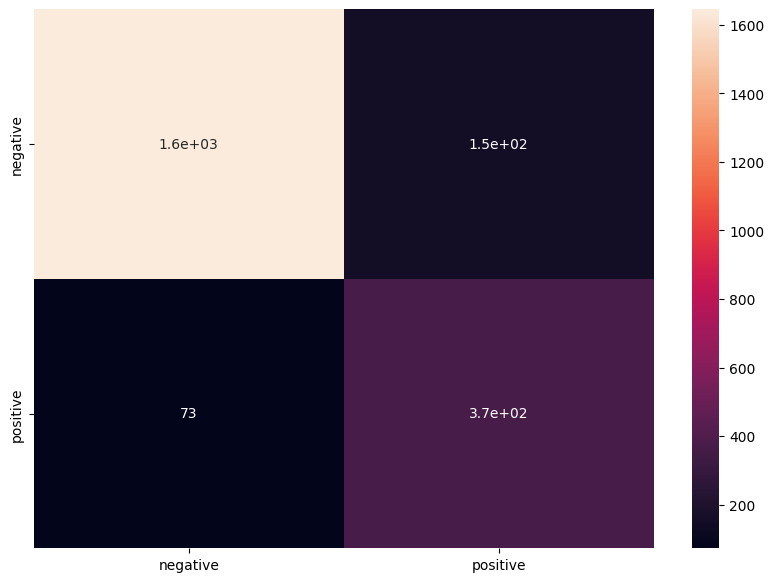

F1 : global 0.8530094620641318, 'negative' : 0.9368, 'positive' : 0.7692, 


In [32]:
print_conf_mat_topN(best_model, dataloaders_dict,
               all_labels_names=image_datasets['val'].class_to_idx.keys(),
               topNresults=None, binary_classif=True)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


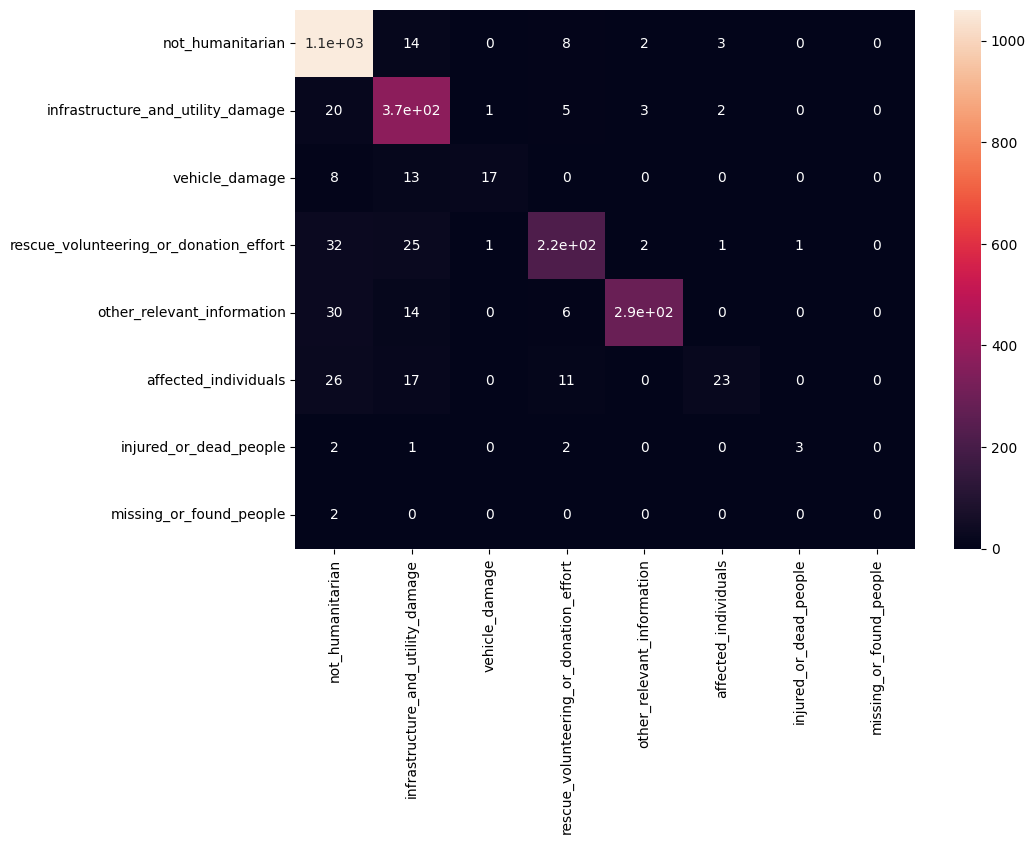

F1 : global 0.6332090045817362, 'not_humanitarian' : 0.9352, 'infrastructure_and_utility_damage' : 0.8667, 'vehicle_damage' : 0.5965, 'rescue_volunteering_or_donation_effort' : 0.8233, 'other_relevant_information' : 0.9100, 'affected_individuals' : 0.4340, 'injured_or_dead_people' : 0.5000, 'missing_or_found_people' : 0.0000, 


In [33]:
topNresults = 2
print_conf_mat_topN(model_ft, dataloaders_dict,
               all_labels_names=image_datasets['val'].class_to_idx.keys(),
               topNresults=topNresults, binary_classif=False)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


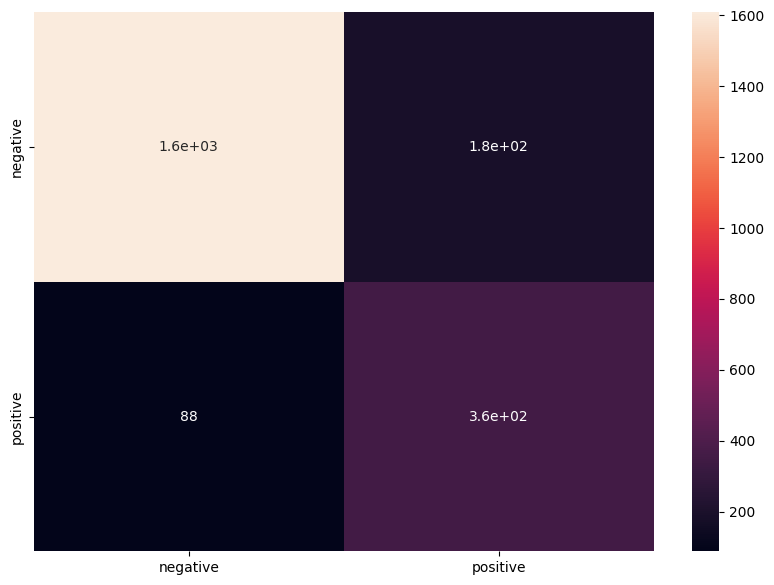

F1 : global 0.8220388250210613, 'negative' : 0.9218, 'positive' : 0.7223, 


In [35]:
print_conf_mat_topN(model_ft, dataloaders_dict,
               all_labels_names=image_datasets['val'].class_to_idx.keys(),
               topNresults=None, binary_classif=True)

## Preguntas

* Que piensas de la matriz de confusion?
* Cuál modelo se desempeñó mejor en el test set? Por qué crees que ocurre esto?
* Porque hace sentido de mirar la accuracy topN cuando N=2 o N=3?
* Que se puede decir cuando agregamos con la valencia?

## Respuestas

1. Para las matrices binarias donde comparo resnet fine-tuneado y squeezenet con feature extraction vemos que tienen un desempeño muy similar (quizás probando con un split de dataset más adecuado para fine-tuning y cambiando SGD por Adam podríamos haber visto cambios más significativos), en particular con hartos falsos negativos (malas para clasificar imagenes "humanitarias") pero muy buenas para clasificar imagenes no humanitarias

2. El mejor modelo (basandonos en acc y weighted F1) resultó ser el único fine-tuneado a partir de la arquitectura de resnet, esto tiene sentido dado que feature extraction limita el aprendizaje a solo adaptar las últimas capas cuando entrenar todas las capas permite aprender mejor el dataset

3. Porque si queremos saber el desempeño general de nuestros modelos se puede relajar un poco las restricciones de clasificación (tenemos muchas clases las cuales son dificiles de distinguir entre sí pero con que hayan sido clasificadas dentro de ese "set de clases vecinas" lo consideraremos como un win), a partir de ahí se puede trabajar en ajustar la capacidad de discriminación del modelo para estas clases muy similares

4. Al hacer aggregation (binarización) podemos ver a simple vista si el modelo funciona o no (ignorando las subclases/distinciones finas)

### Test on our own images !

Funny test

In [39]:
from google.colab import files

# Load the best_model
weights_path = "/content/models/resnet_best_model_no_feature_extraction.pt"

best_model, _ = initialize_model(
    model_name="resnet",
    num_classes=num_classes,
    feature_extract=False,
    use_pretrained=False
)
best_model.load_state_dict(torch.load(weights_path, map_location=device))
best_model = best_model.to(device)

def show_predictions(best_model, verbose=False):
    """
    Upload an image and look at the predictions
    """

    # Get the image
    uploaded = files.upload()

    if len(uploaded.keys()) > 1:
      for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
    elif len(uploaded.keys()) == 1:
      fn = list(uploaded.keys())[0]
      print('User uploaded file "{name}" with length {length} bytes'.format(
          name=fn, length=len(uploaded[fn])))
    else:
      print('Error: file not uploaded')

    im = Image.open(fn)
    width, height = im.size

    ratio_resize = 500./width # so it becomes "more or less" like an image of the corpus of size 500*390

    # If Resnet, input_size = 224
    input_size = 224

    # Preprocess the image
    img_preproc = transforms.Compose([
            transforms.Resize([int(width*ratio_resize), int(height*ratio_resize)]),
            # transforms.RandomResizedCrop(input_size),
            # transforms.RandomHorizontalFlip(),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    img_input = img_preproc(im)

    if verbose: print(img_input.shape)

    # Calculate outputs
    output_resnet = best_model(img_input.unsqueeze(0).cuda())[0]
    preds = torch.nn.functional.softmax(output_resnet, dim=0)

    # Show images and results
    dico_labels = image_datasets['val'].class_to_idx
    str_to_write = "Predictions:\n"

    # to sort them from the most to the least probable
    order_descending = np.argsort([k.cpu().detach().numpy() for k in preds])[::-1]

    list_items = list(dico_labels.items())
    # for label, label_idx in dico_labels.items()[order_descending]:
    for idx_order in order_descending:
          label, label_idx = list_items[idx_order]
          str_to_write += "'{}' : {:.2f}\n".format(label, 100*preds[label_idx])
    print(str_to_write)

    plt.imshow(np.asarray(im))

Saving terremoto.jpg to terremoto.jpg
User uploaded file "terremoto.jpg" with length 165138 bytes
Predictions:
'not_humanitarian' : 77.83
'infrastructure_and_utility_damage' : 7.30
'rescue_volunteering_or_donation_effort' : 7.14
'other_relevant_information' : 6.42
'affected_individuals' : 0.87
'vehicle_damage' : 0.23
'injured_or_dead_people' : 0.16
'missing_or_found_people' : 0.05



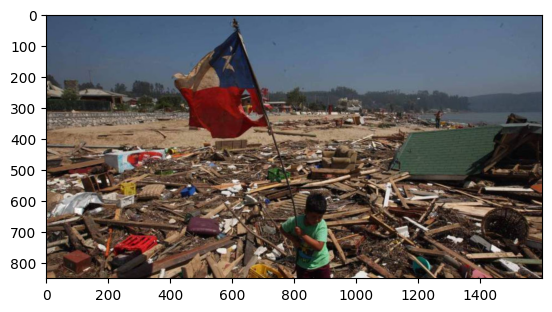

In [41]:
show_predictions(best_model)

## Preguntas

* Qué es un modelo pre-entrenado? Qué significa fine-tunear un modelo?
* Cuáles son las diferencias principales entre entrenar un modelo desde cero y usar Transfer Learning?
* Que pasa con las curvas de aprentizaje cuando utilizamos representaciones viniendo de un modelo ya pre-entrenado?
* A qué hace referencia Layer Freezing? ¿Cuáles podrían ser las ventajas de hacer esto?
* Cuales son las differencias entre extractar los atributos y fine-tunear la ultima capa o fine-tunear todos los parametros del red? Que pasa con las curvas de apprentizaje?
* Cual es el efecto de la aumentacion de datos? Como se puede ver? Que pasa con las curvas de aprentizaje?

## Respuestas
1. Un modelo que ya tiene sus paramétros entrenados usando algún dataset (ImageNet en este caso), fine tunear sería usar una arquitectura ya hecha y ajustar sus parámetros entrenables ("descongelando" las últimas capas o el modelo entero) para una task en particular

2. Que en lugar de inicializar los parametros de una red (ya sea random o con algún algoritmo para inicializar de mejor forma los pesos) y gastar mucho recurso computacional + tiempo aprendiendo patrones básicos con transfer learning hacemos uso de modelos ya entrenados con datasets aprovechando sus pesos (y por ende capacidad de detectar patrones básicos), reduciendo recursos y tiempo de entrenamiento sin sacrificar performance

3. Es baja, la accuracy inicial ya parte siendo alta dado que el modelo ya "sabe" reconocer características útiles para nuestra actual task y la convergencia es más rápida que sin un modelo pre-entrenado

4. Significa mantener los pesos de cierta(s) capa(s) y mantenerlas fijas/no entrenarlas entre épocas, además de preservar las representaciones que ya se sabe la red disminuye el tiempo de entrenamiento

5. Con feature extraction solo modificamos el clasificador para adaptarlo a nuestras clases, fine tunear últimas capas es lo mismo con un grado más de relajo dando oportunidad de entrenar las capas mlp del pipeline (al menos así he visto para redes convolucionales), fine tunear todo es self explanatory, se descongelan todos los pesos y se aprovecha la arquitectura del modelo base para entrenar cada capa

6. Hacer los modelos más robustos a transformaciones e incrementar el tamaño del dataset (muy útil para clases desbalanceadas reduciendo overfitting), en mi caso no hice pruebas sin transformaciones pero en general esperaríamos que al modelo le cueste más entrenar al aplicar transformaciones (dado que se vuelve más difícil la clasificación y porque el dataset es más grande) pero tenga una mejor capacidad de generalización